In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller

In [ ]:
df = pd.read_csv('macro_data_cleaned.csv', parse_dates=['Date'])
df = df.set_index('Date')

In [ ]:
exog = df[['Inflation', 'Unemployment', 'Interest_Rate', 'GDP',
           'Industrial_Output', 'Money_Supply', 'Consumer_Confidence',
           'Treasury_Yield']]

y = df['SP500_Returns']

In [ ]:
result = adfuller(y.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -11.302943834927285
p-value: 1.293994172710107e-20


In [ ]:
model = auto_arima(
    y,
    exogenous=exog,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=1.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4617.326, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=4618.140, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4618.070, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=4615.911, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4617.899, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.50 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=4619.396, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=4619.581, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 2.793 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  801
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -2304.95

In [ ]:
model.fit(y, exogenous=exog)

ARIMA(order=(1, 0, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

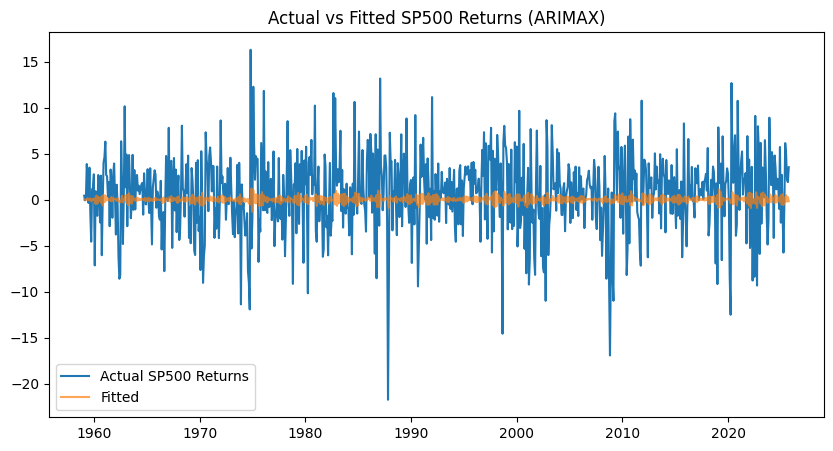

In [ ]:
fitted = model.predict_in_sample(exogenous=exog)
plt.figure(figsize=(10,5))
plt.plot(y, label="Actual SP500 Returns")
plt.plot(y.index, fitted, label="Fitted", alpha=0.7)
plt.title("Actual vs Fitted SP500 Returns (ARIMAX)")
plt.legend()
plt.show()

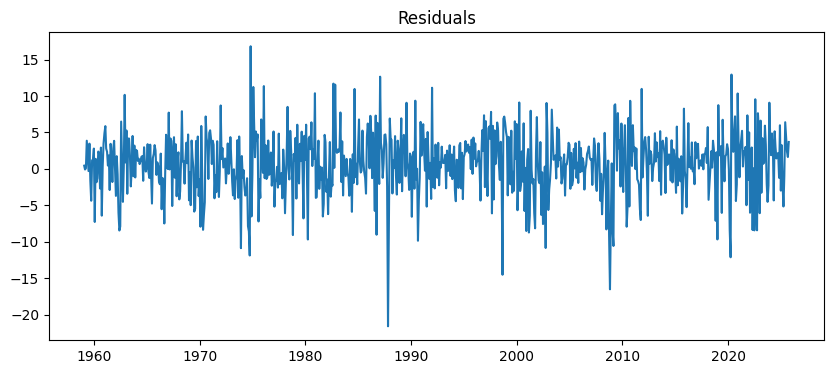

In [ ]:
residuals = y - fitted

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

<Axes: title={'center': 'Residual Histogram'}, ylabel='Frequency'>

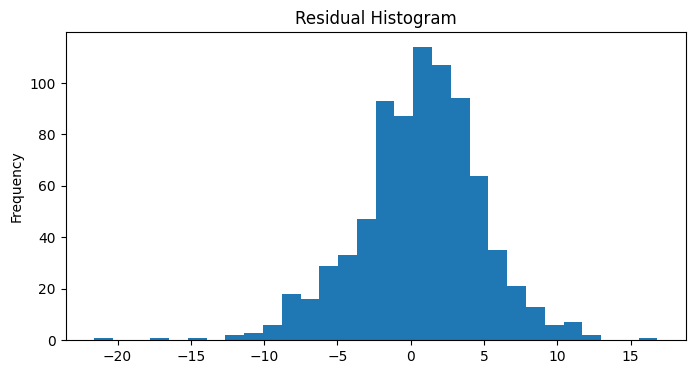

In [ ]:
residuals.plot(kind='hist', bins=30, figsize=(8,4), title='Residual Histogram')

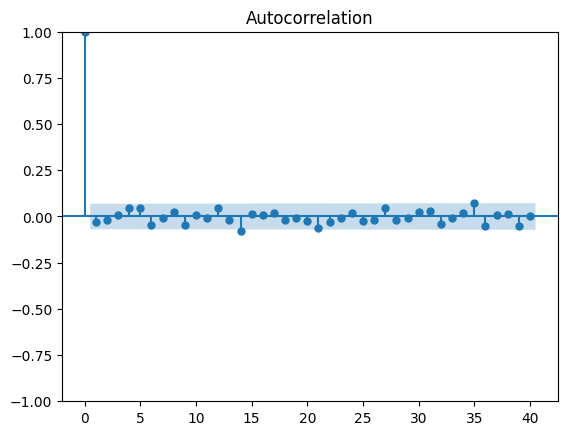

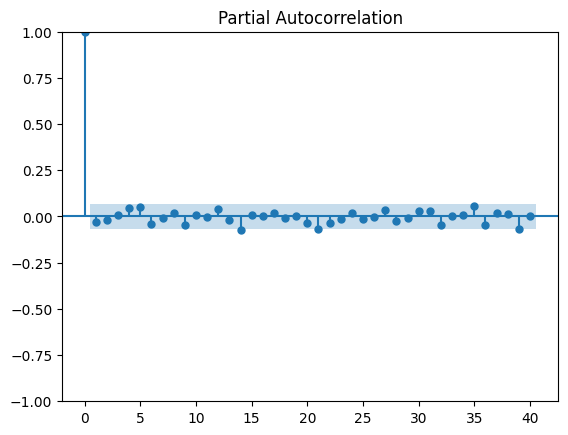

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(residuals.dropna(), lags=40)
plot_pacf(residuals.dropna(), lags=40)
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
10  8.193985   0.609895
